<h1> Hidden Markov Models (HMM)

An HMM is a probabilistic model for sequential data.

The main difference compared to a Bayesian Network:

Bayesian Network:</br>
Relationships between variables

Whereas an HMM:</br>
Variables changing over time

### We have two types of variables:

1. Hidden States
Something we do not observe directly.

2. Observations
Something we observe.

### Components of an HMM

Each HMM consists of 5 components:

1. States: A set of hidden states
2. Observations: Observations
3. Initial Probability: Initial probability
4. Transition Probability: State transition probability
5. Emission Probability: Probability of an observation from a state

### HMM Applications

1. Speech Recognition
2. NLP
Before Deep Learning models:
- Part-of-Speech Tagging
- Named Entity Recognition
3. Bioinformatics
4. DNA sequence analysis
5. Finance
6. Market regime detection

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

from src.hmm import HiddenMarkovModel

<h3> Step 1: Building a simple initial model

In [2]:
states = ["Sunny", "Rainy"]

observations = ["Walk", "Shop", "Clean"]

start = {
    "Sunny":0.6,
    "Rainy":0.4
}

transition = {

    "Sunny":{
        "Sunny":0.8,
        "Rainy":0.2
    },

    "Rainy":{
        "Sunny":0.3,
        "Rainy":0.7
    }
}

emission = {

    "Sunny":{
        "Walk":0.6,
        "Shop":0.3,
        "Clean":0.1
    },

    "Rainy":{
        "Walk":0.1,
        "Shop":0.2,
        "Clean":0.7
    }
}

In [3]:
hmm = HiddenMarkovModel(
    states,
    observations,
    start,
    transition,
    emission
)

<h3> Step 2: Forward Algorithm

In [4]:
hmm.forward(
    [
        "Walk",
        "Shop",
        "Clean"
    ]
)

0.0302

In [5]:
hmm.forward(
    [
        "Walk",
        "Shop"
    ]
)

0.11

In [6]:
hmm.forward(
    [
        "Clean",
        "Walk"
    ]
)

0.1

In [7]:
hmm.forward(
    [
        "Walk",
        "Clean"
    ]
)

0.09999999999999999

<h3> Step 3: Viterbi Algorithm

In [8]:
hmm.viterbi(
    [
        "Walk",
        "Shop",
        "Clean"
    ]
)

['Sunny', 'Sunny', 'Rainy']

In [9]:
hmm.viterbi(
    [
        "Walk",
        "Clean",
        "Shop"
    ]
)

['Sunny', 'Rainy', 'Rainy']

In [10]:
hmm.viterbi(
    [
        "Clean",
        "Shop",
        "Walk"
    ]
)

['Rainy', 'Sunny', 'Sunny']

<h3> Step 4: HMM Transition Visualization

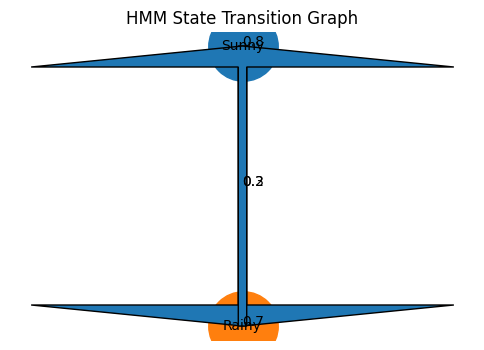

In [13]:
positions = {
    "Sunny":(0,1),
    "Rainy":(0,0)
}

edges = [
    ("Sunny","Sunny",0.8),
    ("Sunny","Rainy",0.2),
    ("Rainy","Sunny",0.3),
    ("Rainy","Rainy",0.7)
]

plt.figure(figsize=(6,4))

for node,(x,y) in positions.items():
    plt.scatter(
        x,
        y,
        s=2500
    )
    plt.text(
        x,
        y,
        node,
        ha="center",
        va="center"
    )

for start,end,prob in edges:
    x1,y1 = positions[start]
    x2,y2 = positions[end]

    plt.arrow(
        x1,
        y1,
        x2-x1,
        y2-y1,
        head_width=0.05,
        length_includes_head=True
    )

    plt.text(
        (x1+x2)/2,
        (y1+y2)/2,
        str(prob)
    )

plt.axis("off")
plt.title(
    "HMM State Transition Graph"
)
plt.show()

<h3> Step 5: HMM Experiment

In [14]:
sequence = [
    "Walk",
    "Walk",
    "Shop",
    "Clean",
    "Clean"
]

In [15]:
probability = hmm.forward(
    sequence
)

probability

0.006234679999999998

In [16]:
best_path = hmm.viterbi(
    sequence
)

best_path

['Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy']

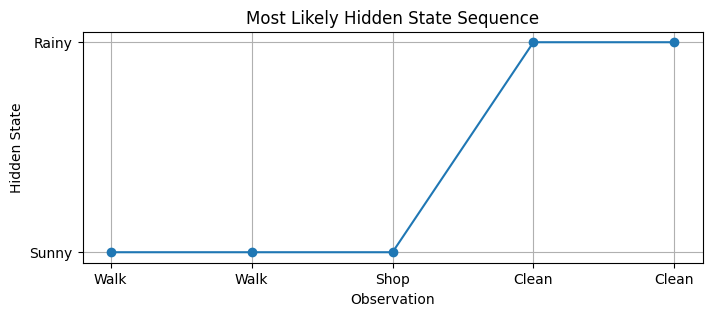

In [17]:
plt.figure(figsize=(8,3))

plt.plot(
    range(len(sequence)),
    best_path,
    marker="o"
)

plt.xticks(
    range(len(sequence)),
    sequence
)

plt.xlabel(
    "Observation"
)

plt.ylabel(
    "Hidden State"
)

plt.title(
    "Most Likely Hidden State Sequence"
)

plt.grid()
plt.show()

<h3> Step 6: Real-world style example (Weather Sequence Experiment)

In [18]:
sequence = [
    "Walk",
    "Walk",
    "Shop",
    "Clean",
    "Clean",
    "Walk",
    "Shop",
    "Clean",
    "Clean",
    "Walk"
]

In [19]:
sequence_probability = hmm.forward(
    sequence
)

print(
    sequence_probability
)

1.6433396079999992e-05


In [20]:
hidden_states = hmm.viterbi(
    sequence
)

hidden_states

['Sunny',
 'Sunny',
 'Sunny',
 'Rainy',
 'Rainy',
 'Sunny',
 'Sunny',
 'Rainy',
 'Rainy',
 'Sunny']

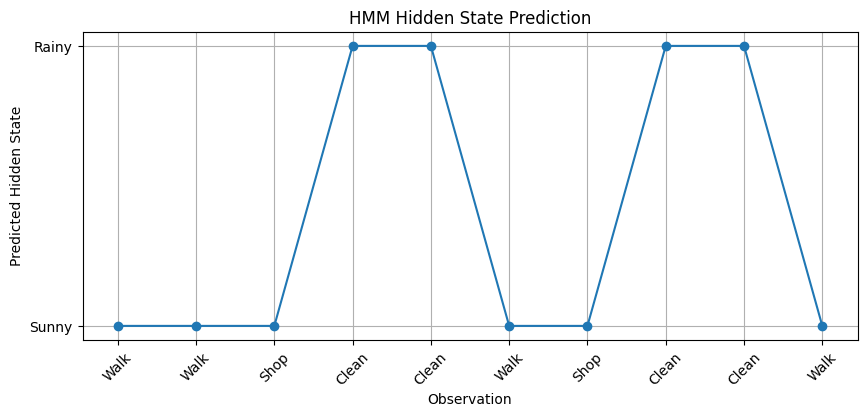

In [21]:
plt.figure(
    figsize=(10,4)
)

plt.plot(
    range(len(sequence)),
    hidden_states,
    marker="o"
)

plt.xticks(
    range(len(sequence)),
    sequence,
    rotation=45
)

plt.xlabel(
    "Observation"
)

plt.ylabel(
    "Predicted Hidden State"
)

plt.title(
    "HMM Hidden State Prediction"
)

plt.grid()
plt.show()

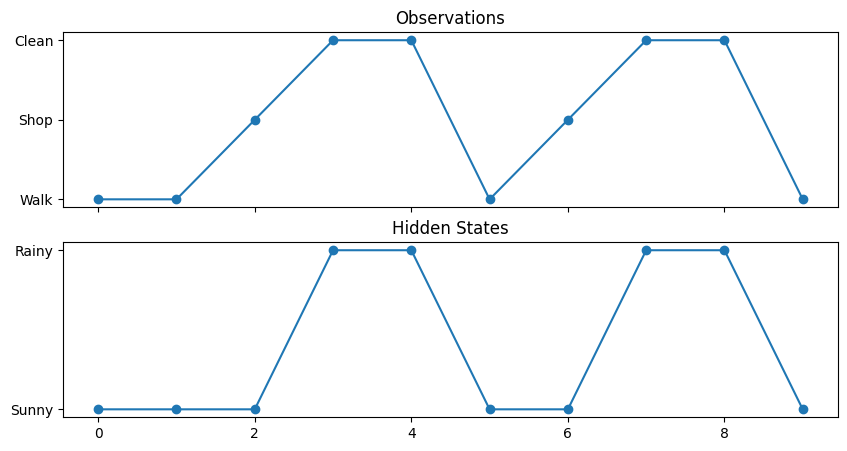

In [22]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(10,5),
    sharex=True
)

ax[0].plot(
    sequence,
    marker="o"
)

ax[0].set_title(
    "Observations"
)

ax[1].plot(
    hidden_states,
    marker="o"
)

ax[1].set_title(
    "Hidden States"
)

plt.show()

### HMM Experiment Conclusion

In this experiment, a Hidden Markov Model was implemented from scratch to model sequential probabilistic data.

The model consisted of hidden states, observations, transition probabilities, and emission probabilities. The Forward algorithm was used to calculate the probability of an observation sequence, while the Viterbi algorithm was used to estimate the most likely hidden state sequence.

The experiment demonstrated how HMMs can infer hidden information from observable events, making them useful for applications such as speech recognition, activity recognition, time-series analysis, and sequence modeling.

The main idea behind HMM can be summarized as:

Observed data → Probabilistic inference → Hidden state estimation